In [6]:
def detect_dataset(line):
    ds = line[0]
    if ds == "RNAndria":
        if line[2].startswith("hsa"):
            return "RNAndria pri-miRNA"
        else:
            return "RNAndria mRNA"
    else:
        return ds

In [7]:
with open("data/chemical_mapping_master_file_filtered.txt") as fh:
    data = fh.readlines()

data = [d.split(", ") for d in data]

In [8]:
import data_utils as du

ds_model_map = {}
for ds in du.chemical_mapping_datasets:
    ds_model_map[ds] = {}
    for m in du.models:
        ds_model_map[ds][m] = []

In [9]:
ds_model_map.keys()

dict_keys(['Ribonanza', 'EternaData', 'RNAndria mRNA', 'RNAndria pri-miRNA'])

In [10]:

for d in data:
    ds = detect_dataset(d)
    model = d[1]
    acc = float(d[5])
    ds_model_map[ds][model].append(acc)

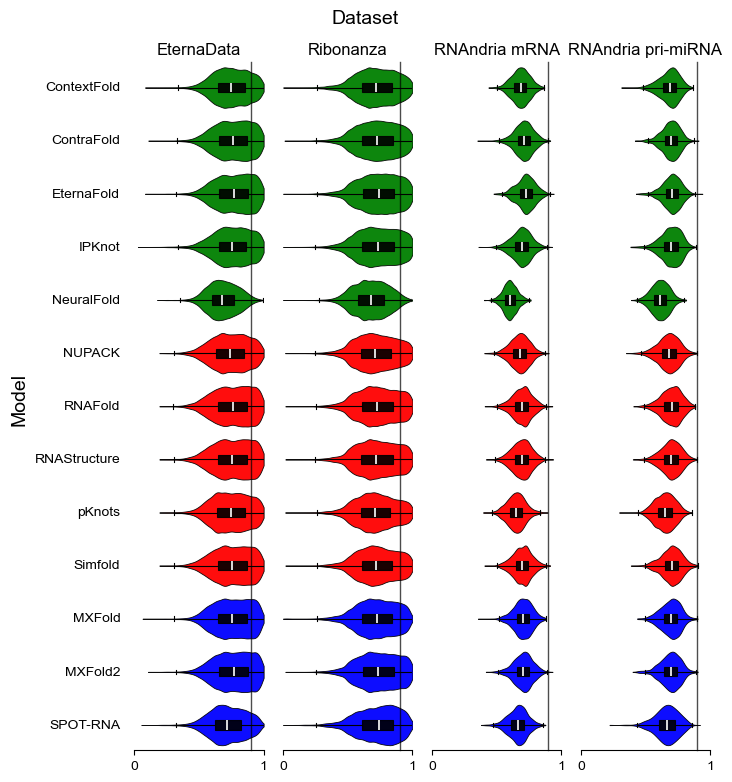

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D


model_order = [
    "ContextFold", "ContraFold", "EternaFold", "IPKnot", "NeuralFold",
    "NUPACK", "RNAFold", "RNAStructure", "pKnots", "Simfold",
    "MXFold", "MXFold2", "SPOT-RNA"
]

dataset_order = ["EternaData", "Ribonanza", "RNAndria mRNA", "RNAndria pri-miRNA"]

n_rows = len(model_order)
n_cols = len(dataset_order)

fig_w = max(1.8 * n_cols, 7)
fig_h = max(0.4 * n_rows, 8)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(fig_w, fig_h),
    squeeze=False,
    sharex=False,
    sharey=False
)

for row_idx, model in enumerate(model_order):
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = 'Arial'

    for col_idx, dataset in enumerate(dataset_order):
        ax = axes[row_idx, col_idx]

        values = ds_model_map.get(dataset, {}).get(model, [])
        values = [v for v in values if v is not None and not np.isnan(v)]

        violin = ax.violinplot(
            values,
            positions=[0],
            widths=0.8,
            showmeans=False,
            showmedians=False,
            showextrema=False,
            vert=False
        )

        model_color = du.get_model_color(model)

        for body in violin["bodies"]:
            body.set_facecolor(model_color)
            body.set_edgecolor("black")
            body.set_alpha(0.95)
            body.set_linewidth(0.6)

        # Add inner boxplot inside the violin
        box = ax.boxplot(
            values,
            positions=[0],
            widths=0.18,
            vert=False,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(
                facecolor="black",
                edgecolor="black",
                linewidth=0.8,
                alpha=0.9
            ),
            medianprops=dict(
                color="white",
                linewidth=1.2
            ),
            whiskerprops=dict(
                color="black",
                linewidth=0.8
            ),
            capprops=dict(
                color="black",
                linewidth=0.8
            )
        )

        if "cmedians" in violin:
            violin["cmedians"].set_color("black")
            violin["cmedians"].set_linewidth(1.0)

        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(-0.5, 0.5)

        if row_idx == n_rows - 1:
            ax.set_xticks([0.0, 1.0])
        else:
            ax.set_xticks([])

        ax.set_yticks([])
        ax.grid(axis="y", alpha=0.2, linewidth=0.5)

        for spine in ax.spines.values():
            spine.set_visible(False)

        if row_idx == n_rows - 1:
            ax.spines["bottom"].set_visible(True)
            ax.spines["bottom"].set_linewidth(0.8)
            ax.spines["bottom"].set_color("black")

        if col_idx == 0:
            ax.set_ylabel(
                model,
                rotation=0,
                ha="right",
                va="center",
                labelpad=10
            )

        if row_idx == 0:
            ax.set_title(dataset)

# Figure-level labels
fig.text(
    0.5,
    0.975,
    "Dataset",
    ha="center",
    va="center",
    fontsize=14
)

fig.text(
    0.02,
    0.5,
    "Model",
    ha="center",
    va="center",
    rotation="vertical",
    fontsize=14
)

# Leave space for the figure-level labels
plt.subplots_adjust(
    left=0.18,
    right=0.98,
    top=0.92,
    bottom=0.06,
    hspace=0.05,
    wspace=0.15
)

fig.canvas.draw()

threshold = 0.9

for col_idx in range(n_cols):
    top_ax = axes[0, col_idx]
    bottom_ax = axes[-1, col_idx]

    # Convert x=0.9 from data coordinates to figure coordinates
    x_display = top_ax.transData.transform((threshold, 0))[0]
    x_fig = fig.transFigure.inverted().transform((x_display, 0))[0]

    # Get vertical span of the whole column in figure coordinates
    y_bottom = bottom_ax.get_position().y0
    y_top = top_ax.get_position().y1

    line = Line2D(
        [x_fig, x_fig],
        [y_bottom, y_top],
        transform=fig.transFigure,
        color="black",
        linewidth=1,
        alpha=0.7,
        zorder=10
    )

    fig.add_artist(line)

plt.savefig("chem_mapping_violin_plot.png", dpi=500, bbox_inches="tight")
plt.show()

In [16]:
# Make PCA

datapoints = [d[2] for d in data]
datapoints = list(set(datapoints))

dp_model_map = {}
for d in datapoints:
    dp_model_map[d] = {}


for d in data:
    model = d[1]
    dp = d[2]
    score = float(d[5].strip())
    dp_model_map[dp][model] = score


In [20]:
eligible_data_points = {}
for dp, values in dp_model_map.items():
    if len(values) == len(model_order):
        eligible_data_points[dp] = values


print(f"Length of all datapoints: {len(dp_model_map)}")
print(f"Length of filtered datapoints: {len(eligible_data_points)}")

Length of all datapoints: 108295
Length of filtered datapoints: 108269


In [22]:
model_acc_map = {}
for m in model_order:
    model_acc_map[m] = []

for dp, pred_accs in eligible_data_points.items():
    for m in model_order:
        acc = pred_accs[m]
        model_acc_map[m].append(acc)

print("Sanity check:")
for model, values in model_acc_map.items():
    print(f"{model}, n = {len(values)}")


Sanity check:
ContextFold, n = 108269
ContraFold, n = 108269
EternaFold, n = 108269
IPKnot, n = 108269
NeuralFold, n = 108269
NUPACK, n = 108269
RNAFold, n = 108269
RNAStructure, n = 108269
pKnots, n = 108269
Simfold, n = 108269
MXFold, n = 108269
MXFold2, n = 108269
SPOT-RNA, n = 108269


PCA input shape: (13, 108269)
Expected shape: (n_models, n_datapoints)


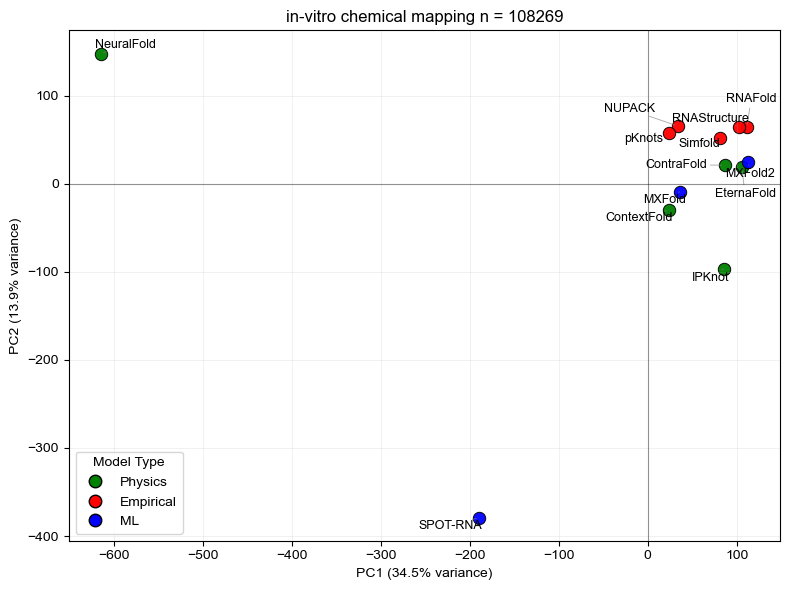

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from adjustText import adjust_text


# ------------------------------------------------------------
# Build PCA input matrix
# Rows = models
# Columns = datapoints / accuracy values
# ------------------------------------------------------------

X = np.array([
    model_acc_map[model]
    for model in model_order
])

print("PCA input shape:", X.shape)
print("Expected shape: (n_models, n_datapoints)")


# ------------------------------------------------------------
# Standardize features
# ------------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ------------------------------------------------------------
# Run PCA
# ------------------------------------------------------------

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


# ------------------------------------------------------------
# Optional: model family mapping for legend
# Adjust this if your categories differ
# ------------------------------------------------------------

model_family_map = {
    "RNAFold": "Physics",
    "RNAStructure": "Physics",
    "NUPACK": "Physics",

    "ContextFold": "Empirical",
    "ContraFold": "Empirical",
    "EternaFold": "Empirical",
    "IPKnot": "Empirical",
    "pKnots": "Empirical",
    "Simfold": "Empirical",

    "NeuralFold": "ML",
    "MXFold": "ML",
    "MXFold2": "ML",
    "SPOT-RNA": "ML",
}

family_color_map = {
    "Physics": "green",
    "Empirical": "red",
    "ML": "blue",
}


# ------------------------------------------------------------
# Plot PCA
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

texts = []

for i, model in enumerate(model_order):
    plt.scatter(
        X_pca[i, 0],
        X_pca[i, 1],
        color=du.get_model_color(model),
        s=80,
        edgecolor="black",
        linewidth=0.7,
        alpha=0.95
    )

    text = plt.text(
        X_pca[i, 0],
        X_pca[i, 1],
        model,
        fontsize=9,
        ha="center",
        va="center"
    )

    texts.append(text)

# Automatically move labels to reduce overlap
adjust_text(
    texts,
    arrowprops=dict(
        arrowstyle="-",
        color="gray",
        linewidth=0.6,
        alpha=0.7
    )
)

plt.axhline(0, color="black", linewidth=0.8, alpha=0.4)
plt.axvline(0, color="black", linewidth=0.8, alpha=0.4)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title(f"in-vitro chemical mapping n = {X.shape[1]}")

# Family legend
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=family,
        markerfacecolor=color,
        markeredgecolor="black",
        markersize=9
    )
    for family, color in family_color_map.items()
]

plt.legend(
    handles=legend_handles,
    title="Model Type",
    loc="best",
    frameon=True
)

plt.grid(alpha=0.25, linewidth=0.5)

plt.tight_layout()
plt.savefig("in_vitro_model_accuracy_pca.png", dpi=500, bbox_inches="tight")
plt.show()